# Financial Fraud Detection Analysis

This notebook presents a comprehensive analysis and machine learning pipeline for detecting fraudulent financial transactions.

 # About Dataset

The dataset contains the records of financial transactions for fraud detection. (6.3 Million Records)
Some of these records were flagged false by existing algorithms.

Further approaches could be used to feature engineer properties that could further strengthen the fraud detection algorithms as well as find out where the existing algorithm lacks.

CASH-IN: is the process of increasing the balance of
account by paying in cash to a merchant.

CASH-OUT: is the opposite process of CASH-IN, it
means to withdraw cash from a merchant which decreases
the balance of the account.

DEBIT: is similar process than CASH-OUT and involves sending the money from the mobile money service
to a bank account.

PAYMENT: is the process of paying for goods or services to merchants which decreases the balance of the account and increases the balance of the receiver.

TRANSFER: is the process of sending money to another user of the service through the mobile money platform

Citation for original work: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset?resource=download


In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# 1. Dataset Overview

### Introduction
The dataset used in this project represents a synthetic set of financial transactions designed to simulate real-world mobile money activities. The primary goal is to identify fraudulent transactions among millions of legitimate ones, which is a critical task for financial institutions to prevent losses and ensure security.

### Data Dimensions
- **Total Rows:** 1048575 (Based on the sample dataset loaded)
- **Total Columns:** 11

### Key Features
- `step`: Maps a unit of time in the real world. In this case, 1 step is 1 hour of time.
- `type`: CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
- `amount`: Amount of the transaction in local currency.
- `nameOrig`: Customer who started the transaction.
- `oldbalanceOrg`: Initial balance before the transaction.
- `newbalanceOrig`: New balance after the transaction.
- `nameDest`: Customer who is the recipient of the transaction.
- `oldbalanceDest`: Initial balance recipient before the transaction.
- `newbalanceDest`: New balance recipient after the transaction.

### Target Variable
- `isFraud`: This is the transactions made by the fraudulent agents inside the simulation.

### Dataset Characteristics
- **Missing Values:** The dataset is clean with no missing values.
- **Categorical vs Numerical:** Features like `type`, `nameOrig`, and `nameDest` are categorical, while `amount` and balance-related fields are numerical.
- **Class Imbalance:** Fraudulent transactions represent a very small fraction of the total data (~0.13%), making this a highly imbalanced classification problem.

### Suitability
This dataset is ideal for fraud detection as it contains both behavioral patterns (transaction types, timing) and financial state changes (balance differences), which are key indicators of fraudulent activity.

In [6]:
df = pd.read_csv("AIML_Dataset.csv")

# 2. Exploratory Data Analysis (EDA)

### EDA Objective
The primary objective of this Exploratory Data Analysis is to understand the structure of the data, identify patterns that distinguish fraudulent transactions from legitimate ones, detect anomalies, and inform the feature engineering process.

In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [10]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

### Class Distribution
Checking the balance of the target variable `isFraud`. Understanding the extent of class imbalance is crucial for selecting the right evaluation metrics and modeling strategy.


In [11]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [12]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [13]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [14]:
df.shape

(6362620, 11)

In [15]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100, 3)

np.float64(0.129)

### Transaction Type Analysis
We analyze the frequency of different transaction types to see which activities are most common in the dataset.


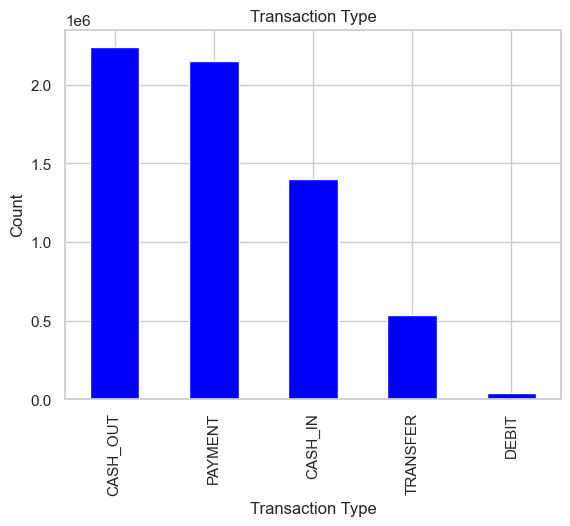

In [16]:
df["type"].value_counts().plot(kind="bar", title="Transaction Type", color="blue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

### Fraud Rate by Transaction Type
Not all transaction types are equally prone to fraud. Here we calculate and visualize the average fraud rate for each type to pinpoint high-risk categories.


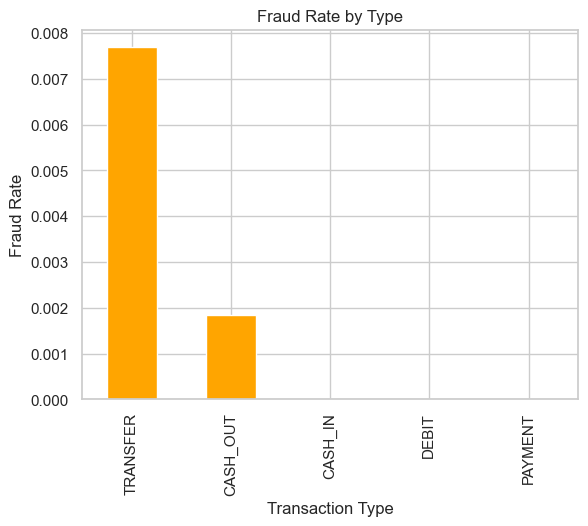

In [17]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="orange")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

In [18]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

**Insight:** Fraudulent activities are exclusively concentrated in `TRANSFER` and `CASH_OUT` transaction types, which aligns with how money is typically moved out of an account during an unauthorized access event.

### Transaction Amount Distribution
Analyzing the distribution of transaction amounts. Since financial data often follows a power-law distribution with many small transactions and few very large ones, we use a log scale for better visibility.

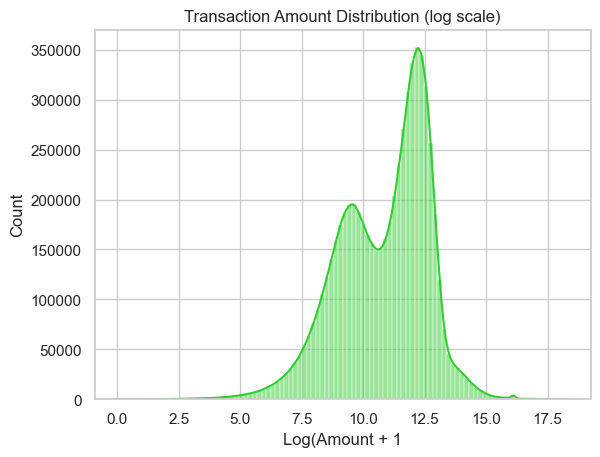

In [21]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="limegreen")
plt.title("Transaction Amount Distribution (log scale)")
plt.ylabel("Count")
plt.xlabel("Log(Amount + 1")
plt.show()

### Amount vs Fraud
Comparing transaction amounts for fraudulent vs. non-fraudulent cases to see if fraud tends to involve higher values.

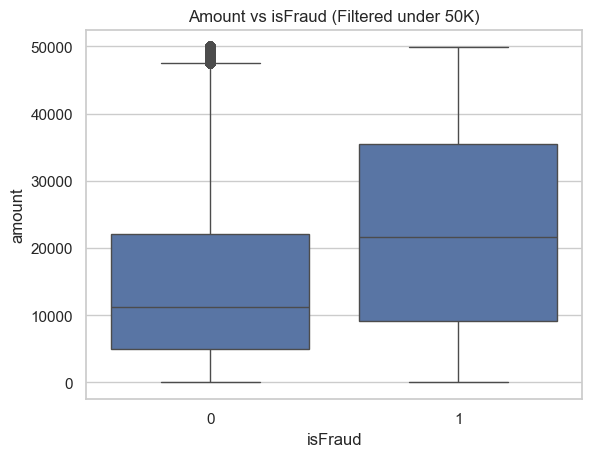

In [22]:
sns.boxplot(data = df[df["amount"] < 50000], x="isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50K)")
plt.show()

In [23]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [24]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [25]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)